Here, we ask how well the global distribution of our predicted data matches our real data. To do so, we will draw on metrics from batch correction benchmarking studies, namely [here](https://doi.org/10.1038/s41587-020-00748-9). This study presents two key metrics:

1. Clusterability: this shows how well biologically distinct groups separate in the data. We will use the NMI metric to quantify clusterability. 
2. Mixability: this shows how well biologically similar groups align in the data. With regards to batch correction, this typically asks how well the same cell type from different batches clusters together. In our case, we use it to see how well predicted and actual data group; so predicted and actual data are analogous to batches. To quantify mixability, we use the modified alignment score. The original score was developed [here](https://doi.org/10.1038/nbt.4096) and the modified version can be found [here](https://doi.org/10.1038/s41587-020-00748-9).

Notes:
- While the batch correction metrics use this for cell type, we use it for the combination of cell type and stimulation condition. 
- In this case, our "batch" is our predicted vs actual data. 

Baselines: We need some baseline metrics to compare our predicted values to. For each baseline, we first duplicate the values of our actual test/OOD cells and concatenate them to our actual data but labeled as "predicted". 

As the number of cells in each condition can effect the metrics and the model is generative such that this can vary from counterfactual to counterfactual, or fold to fold, we generate a different baseline for each instance. The number of values we duplicate per condition matches that of the specific counterfactual (the specific prediction). For each condition: If there are a fewer number of cells in the prediction than the actual data, we take a random subset without replacement to match it. If there are more cells in the prediction than the actual data, we randomly choose with replacement.  

1. baseline NMI: NMI of the concatenated dataset
2. Alignment score: Here, we have two baselines based on two expectations. Expectation 1: our actual and predicted OOD will have high alignment, as they represent the same conditions. Expectation 2: our actual train data and predicted OOD data will have low alignment, as they represent different conditions. Thus, we calculate the alignment score between actual and predicted OOD of the concatenated, and between in-distribution actual and OOD predicted. 

To recalculate this on the predicted data, we project the predictions into the latent space of the acual data with the existing PC model calculated on the actual data in Notebook 03. We then recalculate the neighbors graph and re-run clustering on the combined projected data, using the resolution identified in notebook 03 that optimized NMI between condition and cluster label.  

In [1]:
import os
from typing import Literal, List

import pandas as pd
import scanpy as sc
import numpy as np

import torch

from sklearn.metrics import normalized_mutual_info_score
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS.preprocess import embed_tf_activity, get_alignment_score

sys.path.insert(1, '../../.')
from Kang_utils import get_prediction, rev_stim

In [4]:
seed = 888
device = "cuda" if torch.cuda.is_available() else "cpu"

author = 'Kang'
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'



In [6]:
n_cores = 20
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

Load the model and associated data:

In [7]:
tf_adata = io.read_tfad(os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))
tf_adata.obs['condition'] = tf_adata.obs['stim'].astype(str) + '^' + tf_adata.obs['seurat_annotations'].astype(str)

adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'kang_expr_scored.h5ad'))
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_sn_ppis.csv'), index_col = 0)

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# params
calculation_type = 'project' # project data rather than embed
n_neighbors = 15 # clustering as before
run_umap = True # also get the prediction umaps in addition to pca
best_resolution = tf_adata.uns['leiden']['params']['resolution']

In [8]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

In [9]:
trainer = io.read_pickled_object(os.path.join(data_path, 'processed', 'Kang_fullbest_trainer.pickle'))
mod = trainer.mod

test_cells = open(os.path.join(data_path, 'processed', 'data_split_barcodes', 'kang_test.txt')).read().splitlines()
test_conds = sorted(tf_adata.obs.loc[test_cells, 'condition'].unique())
train_cells_all = [barcode for barcode in tf_adata.obs_names if barcode not in test_cells]

# test_cells = trainer.X_test.index.tolist()
# train_cells_all = trainer.X_train.index.tolist()
# test_conds = sorted(tf_adata.obs.loc[test_cells, 'condition'].unique())

#### Get the predictions:

For a given test condition, we are always predicting the same cell type in the opposite stimulation. However, given the flexibility of the counterfactual, we can make the predictions of the OOD cells from a number of gene expression inputs. Specifically, we can predict from the following gene expression inputs:
- in-distribution: all train cells
- opposite: for each test condition, we predict from the same cell type but opposite stimulation condition (these are all in-distribution as well)

Additional options not explored:
- OOD: test cells only
- all: all cells (in-distribution + OOD)
- stimulated: in-distribution stimulated cells
- unstimulated: in-distribution control cells
- cell type: prediction from a specific in-distribution cell type
- condition: prediction from a specific in-distribution cell type and stimulation

In [10]:
def make_baseline(tf_adata, tf_adata_predicted):
    """Makes baseline model based on # of cells in each condition of the predictd values"""
    barcodes = []
    for cond, n_cells in dict(tf_adata_predicted.obs.condition.value_counts()).items():
        actual_cells = tf_adata.obs[tf_adata.obs.condition == cond].index.tolist()
        if len(actual_cells) >= n_cells:
            np.random.seed(seed)
            actual_cells = np.random.choice(actual_cells, n_cells, replace = False)
        else:
            actual_cells = np.random.choice(actual_cells, n_cells, replace = True)
        barcodes += list(actual_cells)

    tf_adata_base = sc.AnnData(X = tf_adata.to_df().loc[barcodes,:],
                               obs = tf_adata.obs.loc[barcodes, :])
    tf_adata_base.obs_names_make_unique()
    
    return tf_adata_base


def prepare_for_metrics(tf_adata, 
                tf_adata_predicted, 
                resolution,
                calculation_type: Literal['embed', 'project'] = 'project',
                n_neighbors: int = 15, 
                run_umap = True, 
                       ):
    """Combine predictions with actual values and then recalculate neighbors/clusters. 
    Project will project predictions to space calculated on actual values
    Embed will jointly embed the actual and predicted values."""
    

    tf_adata_actual = tf_adata.copy()
    tf_adata_actual.obs['batch'] = 'actual'

    tf_adata_predicted = tf_adata_predicted.copy()
    tf_adata_predicted.obs['batch'] = 'predicted'
    
    tf_adata_ = sc.concat([tf_adata_actual, tf_adata_predicted])
    tf_adata_.obs['barcode'] = tf_adata_.obs.index.tolist()

    if len(set(tf_adata_.obs_names)) < len(tf_adata_.obs_names):
        tf_adata_.obs_names_make_unique()
    
    if calculation_type == 'project': # project the predicted data into the actual data space
        # project new data into PCA space
        pc_rank = tf_adata.uns["pca"]['pca_rank']
        pca_mod = tf_adata.uns['pca']['pca_mod']
        tf_adata_.obsm['X_pca'] = pca_mod.transform(tf_adata_.to_df().values)
        tf_adata_.uns['pca'] = tf_adata.uns['pca'].copy()
        
        # neihgbors/clustering
        embed_tf_activity(tf_adata = tf_adata_,
                          scanpy_pca = None,
                          cluster_col_name = 'new_TF_clusters',
                          n_components = None,
                          pc_rank = None,
                          resolution = resolution,
                          n_neighbors = n_neighbors,
                          nmi_label = None,
                          run_pca = False, 
                          run_umap = False, 
                          cluster_data = True)
        
        # project from PCA space into UMAP space
        if run_umap:
            from scanpy.tools._utils import _choose_representation
            from scanpy._utils import NeighborsView
            
            neighbors = NeighborsView(tf_adata_, 'neighbors')
            X_pca = _choose_representation(
                tf_adata_,
                use_rep=neighbors['params'].get("use_rep", None),
                n_pcs=neighbors['params'].get("n_pcs", None),
                silent=True,
            )

            tf_adata_.obsm['X_umap'] = tf_adata_actual.uns['umap']['umap_mod'].transform(X_pca)
            tf_adata_.uns['umap'] = tf_adata_actual.uns['umap'].copy()
        

    elif calculation_type == 'embed': # embed the combined data again
        embed_tf_activity(tf_adata = tf_adata_,
                          scanpy_pca = True,
                          cluster_col_name = 'new_TF_clusters',
                          n_components = 50,
                          pc_rank = 'automate',
                          resolution = resolution,
                          n_neighbors = n_neighbors,
                          nmi_label = None,
                          run_pca = True, 
                          run_umap = run_umap, 
                         cluster_data = True)
    return tf_adata_

def get_metrics(tf_adata_, train_cells, n_neighbors = 15):
    md = tf_adata_.obs.copy()
    
    # alignment between OOD actual and prediction
    as_cells = md[md.condition.isin(test_conds)].index.tolist()
    
    # sanity checks
    train_md = md[md.barcode.isin(train_cells)]
    if sorted(train_cells) != sorted(train_md.index.tolist()):
        raise ValueError('TF adata object contains different train cells than input')
    if train_md.batch.unique().tolist() != ['actual']:
        raise ValueError('TF adata object contains train cells annotated as predicted')
    if len(set(as_cells).intersection(train_cells)) != 0:
        raise ValueError('OOD cells intersect with train cells')
    
    nmi = normalized_mutual_info_score(tf_adata_.obs.condition, tf_adata_.obs.new_TF_clusters)
    as_OOD = get_alignment_score(adata = tf_adata_[as_cells, :], 
                       batch_key = 'batch', 
                       k = n_neighbors, 
                       normalize = True)

    # alignment between actual train and predicted OOD
    as_cells = md[md.barcode.isin(train_cells)].index.tolist() + md[(md.condition.isin(test_conds)) & (md.batch == 'predicted')].index.tolist()
    as_ID = get_alignment_score(adata = tf_adata_[as_cells, :], 
                       batch_key = 'batch', 
                       k = n_neighbors, 
                       normalize = True)
    
    return nmi, as_OOD, as_ID

In [11]:
cf_map = {'in_distribution': train_cells_all}
counterfactual_types = list(cf_map.keys()) + ['opposite']

In [12]:
# res = pd.DataFrame(columns = ['calculation_type', 'counterfactual_type', 
#                               'nmi', 'as_OOD', 'as_ID', 
#                              'baseline_nmi', 'baseline_as_OOD', 'baseline_as_ID'])

# # for calculation_type in ['project', 'embed']:

# tf_res = {}
# for counterfactual_type in counterfactual_types:
#     tf_adata_predicted = get_prediction(mod = mod, 
#                                         tf_adata = tf_adata, 
#                                         counterfactual_type = counterfactual_type, 
#                                         cf_map = cf_map, 
#                                         train_cells_all = train_cells_all, 
#                                         test_conds = test_conds)
#     tf_adata_base = make_baseline(tf_adata, tf_adata_predicted) # emulate predicted values, but with actual test values
    
#     tf_adata_predicted = prepare_for_metrics(tf_adata, 
#                                        tf_adata_predicted, 
#                                        resolution = best_resolution,
#                                        calculation_type = calculation_type, 
#                                       n_neighbors = n_neighbors, 
#                                             run_umap = True # for visualization
#                                             )
#     nmi, as_OOD, as_ID = get_metrics(tf_adata_predicted, 
#                                      train_cells = train_cells_all, 
#                                      n_neighbors = n_neighbors)
    
#     tf_adata_base = prepare_for_metrics(tf_adata, 
#                                    tf_adata_base, 
#                                    resolution = best_resolution,
#                                    calculation_type = calculation_type, 
#                                   n_neighbors = n_neighbors, 
#                                        run_umap = False)
#     baseline_nmi, baseline_as_OOD, baseline_as_ID = get_metrics(tf_adata_base, 
#                                                                 train_cells = train_cells_all, 
#                                                                 n_neighbors = n_neighbors)
    
    
#     tf_res[counterfactual_type] = tf_adata_predicted
    
    
#     res.loc[res.shape[0], :] = [calculation_type, counterfactual_type, 
#                                 nmi, as_OOD, as_ID, 
#                                baseline_nmi, baseline_as_OOD, baseline_as_ID]
# res.to_csv(os.path.join(data_path, 'processed', author + '_all_clusterability_mixability.csv'))
# io.write_pickled_object(tf_res, os.path.join(data_path, 'interim', author + '_clusterability_ojects.pickle'))

res = pd.read_csv(os.path.join(data_path, 'processed', author + '_all_clusterability_mixability.csv'), 
                  index_col = 0)
tf_res = io.read_pickled_object(os.path.join(data_path, 'interim', author + '_clusterability_ojects.pickle'))

#### Visualize

In [12]:
def adata_dimviz(adata, reduction_type, cats):
    viz_df = pd.DataFrame(adata.obsm['X_' + reduction_type])
    for cat in cats:
        viz_df = pd.concat([viz_df, pd.DataFrame(adata.obs[cat]).reset_index(drop = True)], ignore_index = True, axis = 1)
    if reduction_type=='umap':
        viz_df.columns = [reduction_type.upper() + str(i+1) for i in range(viz_df.shape[1])]
    elif reduction_type=='pca':
        viz_df.columns = [reduction_type.upper()[:-1] + str(i+1) for i in range(viz_df.shape[1])]
    viz_df.columns = viz_df.columns[:-len(cats)].tolist() + cats
    
    return viz_df


In [13]:
viz_df = res.drop(columns = ['calculation_type'])
viz_df = pd.melt(viz_df, id_vars=['counterfactual_type'])

viz_df['variable'] = viz_df.variable.apply(lambda x: x.replace('as_', 'as ')).tolist()
viz_df['variable'] = viz_df.variable.apply(lambda x: 'predicted_' + x if 'baseline' not in x else x).tolist()
viz_df[['type', 'metric']]=viz_df.variable.str.split('_', expand=True)
viz_df.drop(columns = ['variable'], inplace = True)

''

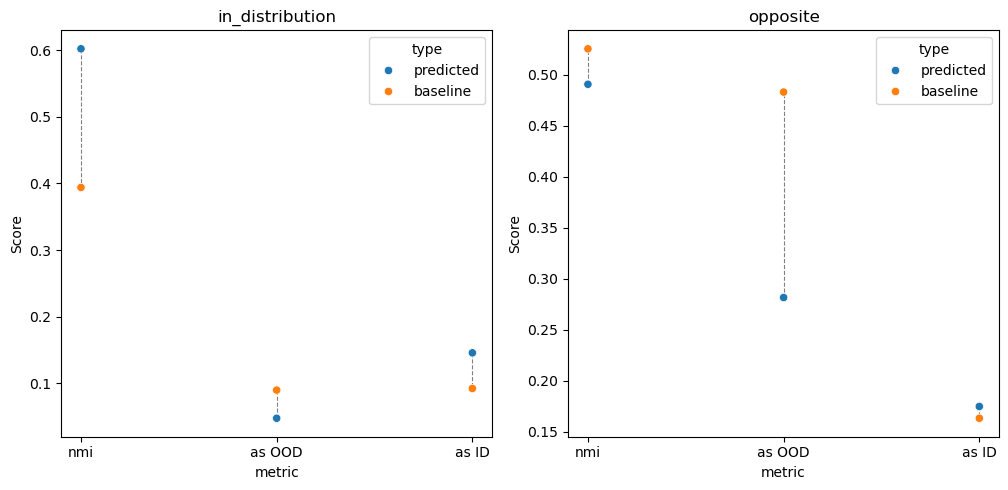

In [14]:
fig, ax = plt.subplots(figsize = (viz_df.counterfactual_type.nunique() * 5.1,5), 
                       ncols = viz_df.counterfactual_type.nunique())

for i, counterfactual_type in enumerate(viz_df.counterfactual_type.unique()):
    viz_df_ = viz_df[viz_df.counterfactual_type == counterfactual_type]

    sns.scatterplot(data = viz_df_, x = 'metric', y = 'value', hue='type', ax = ax[i])

    for metric, group in viz_df_.groupby('metric'):
        if len(group) == 2:  # Ensure there are two points to connect
            ax[i].plot([metric, metric], group['value'], linestyle='--', color='gray', linewidth=0.8, zorder = 0)

    ax[i].set_ylabel('Score')
    ax[i].set_title(counterfactual_type)

fig.tight_layout()
;

#### See [notebook 06Eii](./06Eii_Visualize_Embeddings.ipynb) for visualization of embeddings

# To do:
proceeding section

##### Individual folds

Technically, since the baseline was calculated on all train cells (across all folds), it should be recaculated individually fore each fold. For now, for simplicity (particularly of visualization), we just use the one calculated on all folds

In [118]:
# trainers_best = io.read_pickled_object(os.path.join(data_path, 'processed', 'Kang_trainers_k.pickle'))


In [119]:
# trainers_best.keys()

dict_keys([0, 1, 2, 3, 4])

In [15]:
# res = pd.DataFrame(columns = ['fold', 'calculation_type', 'counterfactual_type', 'nmi', 'as_OOD', 'as_ID'])

# for k, trainer_k in [list(trainers_best.items())[0]]:#trainers_best.items():
#     for counterfactual_type in [counterfactual_types[1]]: #counterfactual_types:
#         mod = trainer_k.mod
#         train_cells = trainer.X_train.index.tolist()
#         cf_map = {'in_distribution': train_cells}

#         tf_adata_predicted = get_prediction(mod = mod, 
#                                             tf_adata = tf_adata, 
#                                             counterfactual_type = counterfactual_type, 
#                                             cf_map = cf_map)
#         tf_adata_all = prepare_for_metrics(tf_adata[train_cells,:], 
#                                            tf_adata_predicted, 
#                                            resolution = best_resolution,
#                                            calculation_type = calculation_type, 
#                                           n_neighbors = n_neighbors)
#         nmi, as_OOD, as_ID = get_metrics(tf_adata_all, 
#                                          train_cells = train_cells, 
#                                          n_neighbors = n_neighbors)
    
    
#         res.loc[res.shape[0], :] = [k, calculation_type, counterfactual_type, nmi, as_OOD, as_ID]
# # res.to_csv(os.path.join(data_path, 'processed', author + '_k_clusterability_mixability.csv'))